In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df_num = pd.read_csv('genres_clean_num.csv')
df_hot = pd.read_csv('genres_clean_comb1.csv')
df_label = pd.read_csv('genres_clean_comb2.csv')

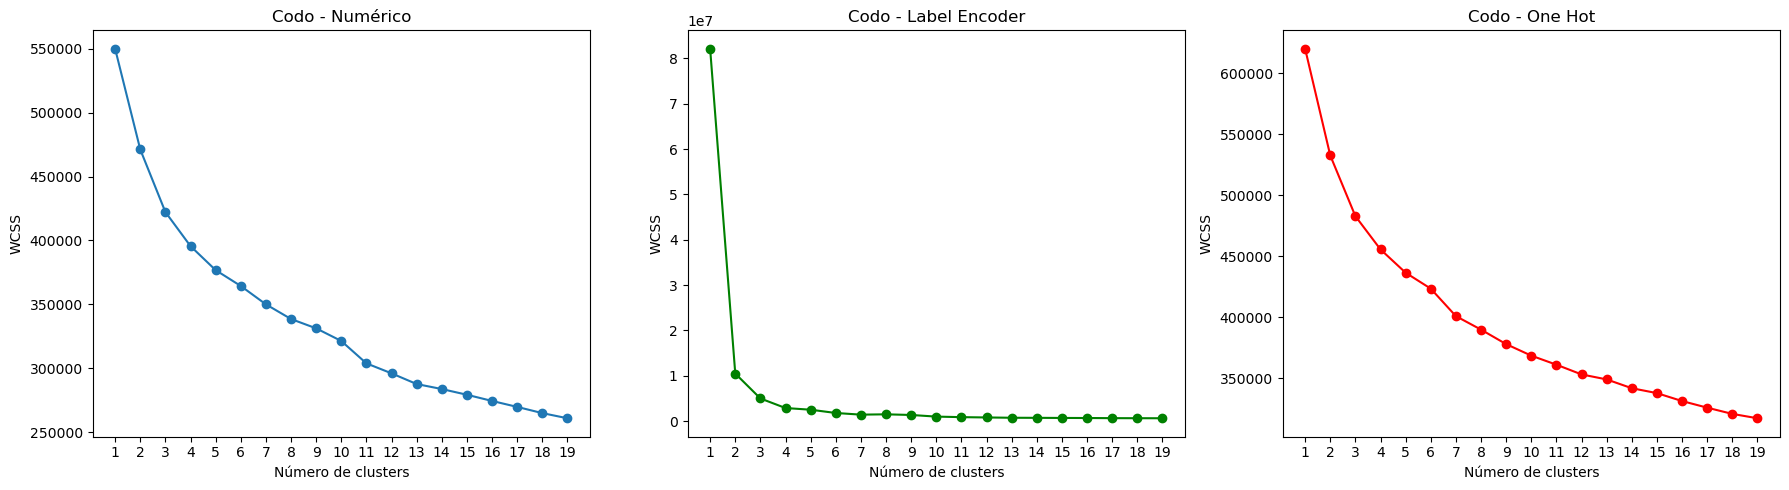

In [5]:
wcss_num = []
for i in range(1, 20):
    model = KMeans(n_clusters=i, init='k-means++', random_state=42)
    model.fit(df_num)
    wcss_num.append(model.inertia_)

wcss_label = []
for i in range(1, 20):
    model = KMeans(n_clusters=i, init='k-means++', random_state=42)
    model.fit(df_label)
    wcss_label.append(model.inertia_)

wcss_hot = []
for i in range(1, 20):
    model = KMeans(n_clusters=i, init='k-means++', random_state=42)
    model.fit(df_hot)
    wcss_hot.append(model.inertia_)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, 20), wcss_num, marker='o')
plt.title('Codo - Numérico')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 20))

plt.subplot(1, 3, 2)
plt.plot(range(1, 20), wcss_label, marker='o', color='green')
plt.title('Codo - Label Encoder')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 20))

plt.subplot(1, 3, 3)
plt.plot(range(1, 20), wcss_hot, marker='o', color='red')
plt.title('Codo - One Hot')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 20))

plt.tight_layout()
plt.show()

In [7]:
datasets = {
    "Numérico": df_num,
    "Label Encoder": df_label,
    "One Hot": df_hot
}
n_clusters_config = {
    "Numérico": 4,
    "Label Encoder": 2,
    "One Hot": 4
}

results = {}

for name, data in datasets.items():
    k = n_clusters_config[name]
    
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(data)
    
    y_kmeans = model.predict(data)
    centers = model.cluster_centers_
    
    silhouette = silhouette_score(data, y_kmeans)
    
    results[name] = {
        "model": model,
        "labels": y_kmeans,
        "centers": centers,
        "silhouette": silhouette
    }
    
    print(f"{name} (k={k}) - Silhouette Score = {silhouette:.3f}")

Numérico (k=4) - Silhouette Score = 0.135
Label Encoder (k=2) - Silhouette Score = 0.787
One Hot (k=4) - Silhouette Score = 0.124


Realmente el Label Encoder nos da un falso resultado positivo ya que al usar números, K-means los interpreta como distancias literales enormes, por eso el Silhouette Sore es alto. El algoritmo encuentra dos bloques artificiales basados en el número del género.

Por otro lado, el Score bajo de los otros dos nos indica que las fronteras entre los estilos de música son borrosas y se solapan. Igualmente hemos elegido 4 clusters pero habíamos visto en el método del codo que la curva era muy suave y no había un pico claro.